In [57]:
from botorch.models.model import Model
from botorch.posteriors import Posterior
from botorch.acquisition.objective import PosteriorTransform

import torch
from torch import Tensor
from torch.nn import Module, ModuleDict, ModuleList

from torch import nn
import numpy as np

In [39]:
class MCDropoutMLP(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.5, n_hidden_layers=3, hidden_dim=100, 
                 hidden_activation=nn.ReLU(), output_activation=None):
        super().__init__()

        self.layers = nn.ModuleList()
        for i in range(n_hidden_layers):
            if i == 0:
                self.layers.append(nn.Linear(input_dim, hidden_dim))
            else:
                self.layers.append(nn.Linear(hidden_dim, hidden_dim))
                
            self.layers.append(nn.Dropout(p=dropout_rate))
            self.layers.append(hidden_activation)

        
        if n_hidden_layers == 0:
            self.layers.append(nn.Linear(input_dim, output_dim))
        else:
            self.layers.append(nn.Linear(hidden_dim, output_dim))

        if output_activation is not None:
            self.layers.append(output_activation)

    def forward(self, input_data, seed=None):
        # Needed so that dropout works
        self.train()
        if seed is not None:
            torch.random.manual_seed(seed)
        for layer in self.layers:
            input_data = layer(input_data)
        return input_data

In [208]:
from botorch.models.ensemble import EnsembleModel
from copy import deepcopy

class MCDropoutModel(EnsembleModel):
    model: MCDropoutMLP
    num_samples: int
    input_dim: int
    output_dim: int
    dropout_rate: float
    n_hidden_layers: int
    hidden_dim: int

    def __init__(self, input_dim: int, output_dim: int, dropout_rate: float = 0.1, 
                 num_samples: int = 30, n_hidden_layers=3, hidden_dim=100, 
                 hidden_activation=nn.ReLU(), output_activation=None):
        
        super(MCDropoutModel, self).__init__()
        self.model = MCDropoutMLP(input_dim, output_dim, 
                                    dropout_rate=dropout_rate,
                                    n_hidden_layers=n_hidden_layers, 
                                    hidden_dim=hidden_dim, 
                                    hidden_activation=hidden_activation, 
                                    output_activation=output_activation)
        
        self.num_samples = num_samples

    def fit(self, X: Tensor, y: Tensor, loss_fn=torch.nn.MSELoss(),
            n_epochs = 500, optim_type = torch.optim.Adam, lr = 1e-3) -> None:
        
        optimizer = optim_type(self.model.parameters(), lr=lr)
        
        for epoch in range(n_epochs):
            pred = self.model(X)
            loss = loss_fn(pred, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
  
    def condition_on_observations(self, X, y, n_cond_epochs=40):
        new_model = deepcopy(self)
        new_model.fit(X, y, n_epochs=n_cond_epochs)
        
        return new_model
        

    def forward(self, X: Tensor) -> Tensor:
        x = X.detach()
        
        # Create the ensemble from predictions from each decision tree.
        samples = torch.stack([self.model(x, seed=i) for i in range(self.num_samples)])

        return samples

In [209]:
torch.manual_seed(3)
train_x = (torch.rand(5)*(2*np.pi)-np.pi)[:, None]
train_y = torch.sin(train_x)

In [210]:
prob_model = MCDropoutModel(1, 1)
prob_model.fit(train_x, train_y)

In [211]:
test_x = torch.linspace(-np.pi, np.pi, 100)[:, None]
true_y = torch.sin(test_x)

In [212]:
posterior = prob_model.posterior(test_x)

In [213]:
check_cond = prob_model.condition_on_observations(torch.tensor([2.])[:, None],
                                             torch.sin(torch.tensor([2.])[:, None]))

In [216]:
posterior_cond = check_cond.posterior(test_x)

In [214]:
import matplotlib.pyplot as plt

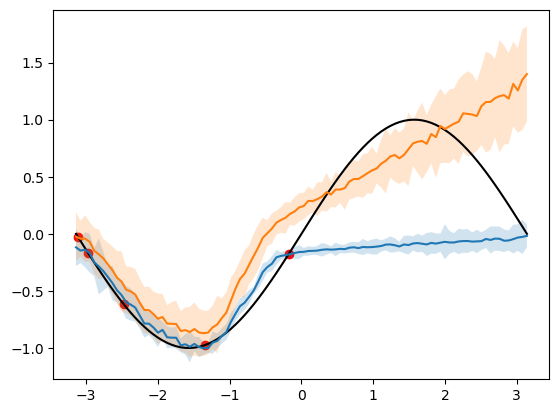

In [220]:
plt.plot(test_x, true_y, c='k')
plt.scatter(train_x, train_y, c='r')

mean = posterior.mean.cpu().detach().flatten()
std = torch.sqrt(post.variance.cpu().detach().flatten())

plt.plot(test_x.flatten(), mean, c='C0')
plt.fill_between(test_x.flatten(), mean-2*std, mean+2*std, fc='C0', alpha=0.2)


mean_cond = posterior_cond.mean.cpu().detach().flatten()
std_cond = torch.sqrt(posterior_cond.variance.cpu().detach().flatten())

plt.plot(test_x.flatten(), mean_cond, c='C1')
plt.fill_between(test_x.flatten(), mean_cond-2*std_cond, mean_cond+2*std_cond, fc='C1', alpha=0.2)